# GPT-1 (Decoder-Only Transformer) 사전학습 — BookCorpus

원본 Transformer(Encoder-Decoder) 코드를 GPT 논문(Radford et al., 2018, *Improving Language Understanding by Generative Pre-Training*) 구조에 맞춰 수정하고, BookCorpus로 언어모델 사전학습(pretraining)을 진행합니다.

**체크리스트 대응**
1. Transformer 대비 변경 필요 부분 서술 → 바로 아래 마크다운 + 코드블럭 주석
2. 모델 입력 형태에 맞는 전처리 → Decoder-only LM이므로 (질문,답변) 쌍이 아닌 **연속 텍스트를 일정 길이로 자른 (input, target) 시퀀스**로 변형 (pretrain만 다룸, fine-tuning 제외)
3. 입력 블럭을 GPT 논문 기준으로 수정 → 학습형(learned) 위치 임베딩 적용, input shape 확인
4. GPT 모델 구성 → 기존 transformer 코드에서 Encoder/Cross-Attention 제거, `model.summary()`/`model.fit()` 포함
5. 입력에 따른 출력 생성 확인 → 텍스트 생성 함수 + 실행 결과


## 1. Transformer 대비 변경이 필요한 부분

| # | 원본 Transformer (Encoder-Decoder) | GPT-1 (Decoder-only) | 이유 |
|---|---|---|---|
| 1 | Encoder 스택 존재 (입력 문장을 양방향으로 인코딩) | **Encoder 전체 제거** | GPT는 번역처럼 "다른 문장을 조건으로" 생성하지 않고, 자기 자신의 이전 토큰만으로 다음 토큰을 예측하는 순수 언어모델이기 때문 |
| 2 | DecoderLayer = Masked Self-Attention + **Cross-Attention** + FFN | DecoderLayer(=GPT Block) = Masked Self-Attention + FFN (**Cross-Attention 제거**) | 참조할 Encoder 출력이 없으므로 Cross-Attention 자체가 불필요 |
| 3 | 위치 인코딩 = **고정된 sin/cos 함수** (학습 파라미터 없음) | 위치 인코딩 = **학습되는 Embedding 레이어** (`nn.Embedding`/`layers.Embedding`) | GPT 논문은 position embedding을 다른 파라미터처럼 학습시킴 (BERT/GPT 계열의 공통 특징) |
| 4 | 학습 데이터 = (질문, 답변) **쌍(pair)**, 정답 시퀀스에 대해서만 loss 계산 | 학습 데이터 = **연속된 텍스트 덩어리**, 문장 내 모든 위치에서 "다음 토큰 예측" loss 계산 | Seq2Seq 지도학습 → 비지도 언어모델 사전학습으로 과제 자체가 바뀜 |
| 5 | 출력층은 Decoder 출력만 사용하는 별도 Linear | 출력층 가중치를 **입력 임베딩과 공유(weight tying)** | GPT-1 논문의 실제 구현 방식 (Press & Wolf, 2017 기법 채택) |
| 6 | 마스킹 = 디코더에만 causal mask, 인코더는 mask 없음(양방향) | 마스킹 = **모든 레이어가 causal mask만 사용** (양방향 attention 자체가 없음) | 인코더가 없으므로 "양방향 참조"라는 개념 자체가 사라짐 |
| 7 | FFN 활성화 함수 = **ReLU** | FFN 활성화 함수 = **GELU** | GPT-1 논문(3.1절)이 명시적으로 ReLU 대신 GELU를 채택 |

위 변경사항은 아래 각 코드 블럭에도 `# [GPT 변경]` 주석으로 표시했습니다.


## 0. 환경 설정

In [1]:
# TensorFlow / Keras 기반 구현 (model.summary(), model.fit() 사용을 위함)
!pip install -q datasets sentencepiece

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import math

print("TensorFlow:", tf.__version__)
print("GPU 사용 가능:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU 사용 가능: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
SAVE_DIR = "/content/drive/MyDrive/gpt1_bookcorpus"
os.makedirs(SAVE_DIR, exist_ok=True)
print("저장 위치:", SAVE_DIR)


Mounted at /content/drive
저장 위치: /content/drive/MyDrive/gpt1_bookcorpus


## 1-2단계: 데이터 로드 및 전처리 (입력 형태에 맞는 변형)

**데이터 출처 및 근거**:
- **원 논문**: Zhu, Y., Kiros, R., Zemel, R., Salakhutdinov, R., Urtasun, R., Torralba, A., & Fidler, S. (2015). *Aligning Books and Movies: Towards Story-like Visual Explanations by Watching Movies and Reading Books*. ICCV 2015 / [arXiv:1506.06724](https://arxiv.org/abs/1506.06724). — 영화 장면과 소설 문장을 정렬하기 위해 대규모 미출간 소설 코퍼스로 문장 임베딩을 학습시킨 것이 원조이며, 이때 사용된 11,000여 권의 소설 코퍼스가 이후 "BookCorpus"라는 이름으로 GPT-1, BERT 등 여러 사전학습 언어모델의 학습 데이터로 널리 재사용되었습니다.
- **크롤러 코드**: [soskek/bookcorpus](https://github.com/soskek/bookcorpus) — 원본 배포가 중단된 뒤 이를 재현하기 위한 저장소이지만, README 자체가 "smashwords.com 크롤링이 불안정하니 HuggingFace datasets 버전을 쓰라"고 권장하고 있습니다.
- **실제 사용 데이터**: [rojagtap/bookcorpus](https://huggingface.co/datasets/rojagtap/bookcorpus) (HuggingFace, 스트리밍)로 가져옵니다.

**[GPT 변경] 데이터 형태 변형**: 챗봇(Q,A) 방식은 "질문 → 답변"이라는 쌍 구조가 필요했지만,
GPT-1은 **비지도 사전학습**이므로 라벨이 필요 없습니다. BookCorpus의 연속된 문장들을 이어붙인 뒤,
`SEQ_LEN` 크기로 잘라 `(input, target)` = `(tokens[:-1], tokens[1:])` 형태로만 만들면 됩니다 (target은 input을 한 칸 밀어낸 것).


In [3]:
from datasets import load_dataset

# 스트리밍으로 로드 (BookCorpus 전체는 74M 문장 이상으로 매우 크므로, 데모/과제 규모에 맞게 일부만 사용)
NUM_SENTENCES = 200_000   # 필요 시 늘리세요 (Colab Pro 컴퓨팅 예산에 맞춰 조정)

raw_dataset = load_dataset("rojagtap/bookcorpus", split="train", streaming=True)

sentences = []
for i, example in enumerate(raw_dataset):
    text = example["text"].strip()
    if text:
        sentences.append(text)
    if len(sentences) >= NUM_SENTENCES:
        break

print(f"수집한 문장 수: {len(sentences):,}")
print("샘플:", sentences[:3])


README.md:   0%|          | 0.00/21.0 [00:00<?, ?B/s]

수집한 문장 수: 200,000
샘플: ['the half-ling book one in the fall of igneeria series kaylee soderburg copyright 2013 kaylee soderburg all rights reserved .', 'isbn : 1492913731 isbn-13 : 978-1492913733 for my family , who encouraged me to never stop fighting for my dreams chapter 1 summer vacations supposed to be fun , right ?', 'i wish i had a better answer to that question .']


In [4]:
import re

def clean_text(text):
    """영어 텍스트 정제: 공백 정규화 + 허용 문자만 남김"""
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\.\,\?\!\'\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

corpus_text = "\n".join(clean_text(s) for s in sentences if clean_text(s))

CORPUS_PATH = "/content/bookcorpus_subset.txt"
with open(CORPUS_PATH, "w", encoding="utf-8") as f:
    f.write(corpus_text)

print(f"정제된 코퍼스 길이: {len(corpus_text):,}자")


정제된 코퍼스 길이: 14,959,120자


## 2단계 (계속): 토크나이저 학습 (SentencePiece BPE)

In [5]:
import sentencepiece as spm

MODEL_PREFIX = "/content/spm_bookcorpus"
VOCAB_SIZE = 16000

spm.SentencePieceTrainer.train(
    input=CORPUS_PATH,
    model_prefix=MODEL_PREFIX,
    vocab_size=VOCAB_SIZE,
    model_type="bpe",
    character_coverage=1.0,
    pad_id=0, unk_id=1, bos_id=2, eos_id=3,
    pad_piece="<pad>", unk_piece="<unk>", bos_piece="<bos>", eos_piece="<eos>",
)

sp = spm.SentencePieceProcessor(model_file=MODEL_PREFIX + ".model")
print("Vocab size:", sp.get_piece_size())
print(sp.encode("This is an example sentence.", out_type=str))


Vocab size: 16000
['▁', 'T', 'h', 'is', '▁is', '▁an', '▁example', '▁sentence', '.']


## 2단계 (계속): 언어모델용 (input, target) 시퀀스 구성

**[GPT 변경]** 전체 코퍼스를 토큰 ID로 변환한 뒤, `SEQ_LEN+1` 길이로 슬라이딩하며 자릅니다.
- `input`  = 토큰[0 : SEQ_LEN]
- `target` = 토큰[1 : SEQ_LEN+1]  (input을 한 칸 뒤로 민 것 — "다음 토큰 예측" 학습 신호)

Q&A 쌍이 아니라 이렇게 **자기 자신을 shift한 것이 곧 정답**이 되는 것이 언어모델 사전학습의 핵심 전처리입니다.


In [6]:
SEQ_LEN = 128  # GPT-1 원 논문은 512지만, 데모/과제 규모를 고려해 축소

all_ids = []
for line in corpus_text.split("\n"):
    all_ids.extend(sp.encode(line, out_type=int) + [sp.eos_id()])

all_ids = np.array(all_ids, dtype=np.int32)
print(f"전체 토큰 수: {len(all_ids):,}")

# SEQ_LEN+1 크기로 겹치지 않게 슬라이딩 (stride=SEQ_LEN)
num_chunks = (len(all_ids) - 1) // SEQ_LEN
inputs = np.zeros((num_chunks, SEQ_LEN), dtype=np.int32)
targets = np.zeros((num_chunks, SEQ_LEN), dtype=np.int32)

for i in range(num_chunks):
    start = i * SEQ_LEN
    chunk = all_ids[start : start + SEQ_LEN + 1]
    inputs[i] = chunk[:-1]
    targets[i] = chunk[1:]

print("inputs shape:", inputs.shape, "| targets shape:", targets.shape)
print("예시 input :", inputs[0][:15])
print("예시 target:", targets[0][:15], " <- input을 한 칸 민 것")


전체 토큰 수: 3,429,019
inputs shape: (26789, 128) | targets shape: (26789, 128)
예시 input : [    9   873  4278  1120   183    45     9  1048    42 10289  3666  1968
    56 15959   133]
예시 target: [  873  4278  1120   183    45     9  1048    42 10289  3666  1968    56
 15959   133   767]  <- input을 한 칸 민 것


In [7]:
BATCH_SIZE = 64

dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
dataset = dataset.shuffle(10000).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

val_size = max(1, num_chunks // 20)
val_dataset = dataset.take(val_size // BATCH_SIZE + 1)
train_dataset = dataset.skip(val_size // BATCH_SIZE + 1)

print("train batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("val batches  :", tf.data.experimental.cardinality(val_dataset).numpy())


train batches: 397
val batches  : 21


## 3단계: GPT 입력 블럭 구현 (GPT 논문 기준)

**[GPT 변경] 위치 정보 추가 방식**: 원본 Transformer는 `sin/cos` 고정 함수를 썼지만,
GPT-1은 `nn.Embedding`과 동일하게 **학습되는 위치 임베딩 테이블**(`layers.Embedding(SEQ_LEN, d_model)`)을 사용합니다.
토큰 임베딩과 위치 임베딩을 더해서 최종 입력을 만드는 구조 자체는 동일합니다.


In [8]:
class TokenAndPositionEmbedding(layers.Layer):
    """[GPT 변경] 원본 PositionalEncoding(고정 sin/cos) -> 학습되는 위치 Embedding으로 교체"""
    def __init__(self, seq_len, vocab_size, d_model, **kwargs):
        super().__init__(**kwargs)
        self.token_emb = layers.Embedding(vocab_size, d_model, name="token_embedding")
        self.pos_emb = layers.Embedding(seq_len, d_model, name="position_embedding")  # 학습 파라미터
        self.d_model = d_model

    def call(self, x):
        seq_len = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=seq_len, delta=1)
        pos_out = self.pos_emb(positions)                 # (seq_len, d_model)
        tok_out = self.token_emb(x) * tf.math.sqrt(tf.cast(self.d_model, tf.float32))  # 원본과 동일한 sqrt(d_model) 스케일링
        return tok_out + pos_out                           # (batch, seq_len, d_model)


# ---- 입력이 정상적으로 구성되는지 확인 ----
test_layer = TokenAndPositionEmbedding(seq_len=SEQ_LEN, vocab_size=VOCAB_SIZE, d_model=256)
test_batch = tf.constant(inputs[:2])
test_out = test_layer(test_batch)
print("토큰 ID 입력 shape :", test_batch.shape)
print("임베딩+위치정보 출력 shape:", test_out.shape, "(batch, seq_len, d_model)")


토큰 ID 입력 shape : (2, 128)
임베딩+위치정보 출력 shape: (2, 128, 256) (batch, seq_len, d_model)


## 4단계: GPT-1 모델 구성 (기존 Transformer 코드를 GPT 논문 기준으로 수정)

**[GPT 변경] DecoderLayer → GPTBlock**: Cross-Attention 서브레이어를 제거하고 Masked Self-Attention + FFN만 남깁니다.
**[GPT 변경] Encoder 클래스 자체를 삭제**하고, GPT 클래스는 `TokenAndPositionEmbedding` + `GPTBlock × N` + 최종 LayerNorm + (임베딩과 가중치를 공유하는) 출력층만으로 구성합니다.


In [9]:
class GPTBlock(layers.Layer):
    """[GPT 변경] 원본 DecoderLayer에서 Cross-Attention을 제거한 버전 (Masked Self-Attention + FFN만 존재)"""
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.att = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads, dropout=dropout)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="gelu"),  # [GPT 변경] 원 논문(3.1절)은 ReLU 대신 GELU 사용
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout)
        self.dropout2 = layers.Dropout(dropout)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        # [GPT 변경] Cross-Attention 없이 causal(삼각행렬) mask만 사용하는 Self-Attention 한 종류만 존재
        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)  # 하삼각 = 미래 토큰 차단
        attn_out = self.att(query=x, value=x, key=x, attention_mask=causal_mask, training=training)
        x = self.norm1(x + self.dropout1(attn_out, training=training))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout2(ffn_out, training=training))
        return x


class GPT1(keras.Model):
    """[GPT 변경] 원본 Transformer(Encoder+Decoder)에서 Encoder를 완전히 제거하고 Decoder만으로 구성한 언어모델"""
    def __init__(self, vocab_size, seq_len, num_layers, d_model, num_heads, ff_dim, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed = TokenAndPositionEmbedding(seq_len, vocab_size, d_model)
        self.blocks = [GPTBlock(d_model, num_heads, ff_dim, dropout) for _ in range(num_layers)]
        self.dropout = layers.Dropout(dropout)
        self.final_norm = layers.LayerNormalization(epsilon=1e-6)
        # [GPT 변경] 출력층: 별도 Dense가 아니라 token embedding 가중치를 그대로 전치해 재사용 (weight tying)
        self.vocab_size = vocab_size

    def call(self, x, training=False):
        x = self.embed(x)
        x = self.dropout(x, training=training)
        for block in self.blocks:
            x = block(x, training=training)
        x = self.final_norm(x)
        # weight tying: (batch, seq_len, d_model) @ (d_model, vocab_size)
        embedding_matrix = self.embed.token_emb.embeddings  # (vocab_size, d_model)
        logits = tf.matmul(x, embedding_matrix, transpose_b=True)  # (batch, seq_len, vocab_size)
        return logits


## 4단계 (계속): model.summary() / model.fit()

In [10]:
# 약 1,200만 파라미터급으로 규모 설정 (기존 챗봇 프로젝트와 동일한 스케일)
D_MODEL = 256
NUM_HEADS = 8
FF_DIM = 640
NUM_LAYERS = 4
DROPOUT = 0.1

gpt = GPT1(
    vocab_size=VOCAB_SIZE, seq_len=SEQ_LEN, num_layers=NUM_LAYERS,
    d_model=D_MODEL, num_heads=NUM_HEADS, ff_dim=FF_DIM, dropout=DROPOUT,
)

# build 호출을 위해 더미 입력 한 번 통과
dummy = tf.zeros((1, SEQ_LEN), dtype=tf.int32)
_ = gpt(dummy)

gpt.summary()


Model: "gpt1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ token_and_position_embedding_1  │ ?                      │     4,128,768 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block (GPTBlock)            │ ?                      │       592,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_1 (GPTBlock)          │ ?                      │       592,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_2 (GPTBlock)          │ ?                      │       592,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpt_block_3 (GPTBlock)          │ ?                      │       592,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_8           │ (1, 128, 256)          │           512 │
│ (LayerNormalization)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,500,352 (24.80 MB)

 Trainable params: 6,500,352 (24.80 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
class WarmupCosineSchedule(keras.optimizers.schedules.LearningRateSchedule):
    """Transformer 논문 방식의 warmup + 역제곱근 감쇠 학습률 스케줄"""
    def __init__(self, d_model, warmup_steps=1000):
        super().__init__()
        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)


lr_schedule = WarmupCosineSchedule(D_MODEL, warmup_steps=1000)
optimizer = keras.optimizers.Adam(lr_schedule, beta_1=0.9, beta_2=0.98, epsilon=1e-9)

loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

gpt.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])


In [15]:
EPOCHS = 30  # 데이터 규모/컴퓨팅 예산에 맞게 조정하세요

history = gpt.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
)


Epoch 1/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 68s 172ms/step - accuracy: 0.2794 - loss: 3.9031 - val_accuracy: 0.2890 - val_loss: 3.7998
Epoch 2/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 167ms/step - accuracy: 0.2822 - loss: 3.8684 - val_accuracy: 0.2950 - val_loss: 3.7551
Epoch 3/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.2849 - loss: 3.8344 - val_accuracy: 0.2970 - val_loss: 3.7135
Epoch 4/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 167ms/step - accuracy: 0.2871 - loss: 3.8058 - val_accuracy: 0.3005 - val_loss: 3.6718
Epoch 5/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 167ms/step - accuracy: 0.2891 - loss: 3.7797 - val_accuracy: 0.3026 - val_loss: 3.6547
Epoch 6/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.2909 - loss: 3.7579 - val_accuracy: 0.3074 - val_loss: 3.6226
Epoch 7/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.2929 - loss: 3.7348 - val_accuracy: 0.3079 - val_loss: 3.5993
Epoch 8/30
397/397 ━━━━━━━━━━━━━━━━━━━━ 66s 165ms/step - accuracy: 0.2945 - loss: 3

/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 45796 (\N{HANGUL SYLLABLE DA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1648/1204089970.py:14: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_

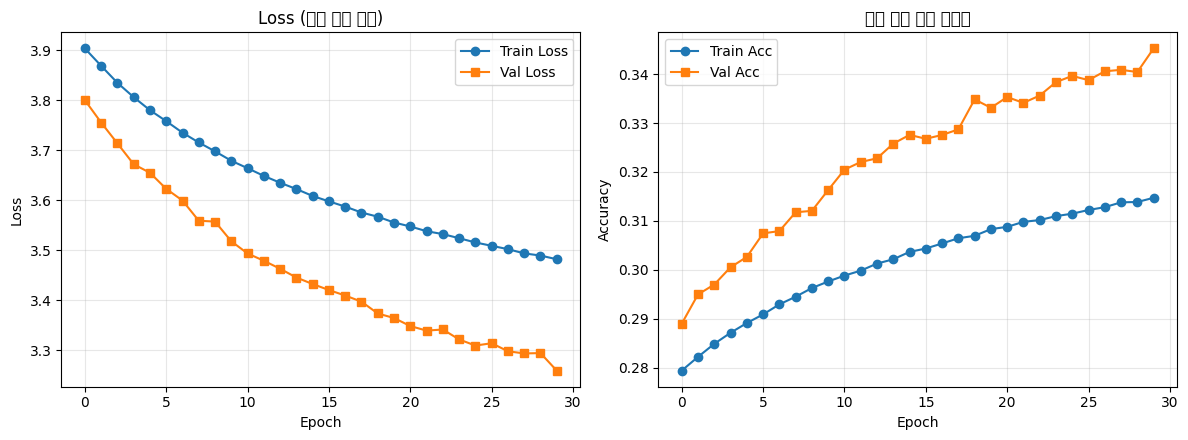

체크포인트 저장 완료


In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history.history['loss'], marker='o', label='Train Loss')
axes[0].plot(history.history['val_loss'], marker='s', label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Loss (다음 토큰 예측)')

axes[1].plot(history.history['accuracy'], marker='o', label='Train Acc')
axes[1].plot(history.history['val_accuracy'], marker='s', label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[1].set_title('다음 토큰 예측 정확도')

plt.tight_layout()
plt.savefig(f"{SAVE_DIR}/gpt1_loss_curve.png", dpi=130)
plt.show()

gpt.save_weights(f"{SAVE_DIR}/gpt1_bookcorpus.weights.h5")
print("체크포인트 저장 완료")


## 5단계: 입력에 따른 출력 생성 확인

GPT는 Encoder-Decoder처럼 "정답이 있는 번역"이 아니라, **주어진 프롬프트 뒤에 이어질 텍스트를 스스로 생성**합니다.
출력 품질과 무관하게, 프롬프트 입력 → 토큰 생성 루프가 정상적으로 동작하는지 확인합니다.


In [17]:
def generate(prompt, max_new_tokens=40, temperature=1.0):
    """프롬프트를 이어서 텍스트를 생성하는 함수 (자기회귀, top-1 또는 온도 샘플링)"""
    ids = sp.encode(prompt, out_type=int)
    ids = ids[-SEQ_LEN:]  # 너무 길면 뒤에서부터 SEQ_LEN만큼만 사용

    for _ in range(max_new_tokens):
        context = ids[-SEQ_LEN:]
        pad_len = SEQ_LEN - len(context)
        padded = context + [sp.pad_id()] * pad_len
        x = tf.constant([padded], dtype=tf.int32)

        logits = gpt(x, training=False)                  # (1, SEQ_LEN, vocab)
        next_logits = logits[0, len(context) - 1] / temperature
        next_id = int(tf.random.categorical(next_logits[None, :], num_samples=1)[0, 0])

        if next_id == sp.eos_id():
            break
        ids.append(next_id)

    return sp.decode(ids)


test_prompts = [
    "The old man walked slowly into the",
    "She looked at him and said",
    "It was a dark and stormy",
]

for p in test_prompts:
    print("=" * 60)
    print("입력 :", p)
    print("생성 :", generate(p, max_new_tokens=30))


입력 : The old man walked slowly into the
생성 :  ⁇ he old man walked slowly into the shower .
입력 : She looked at him and said
생성 :  ⁇ he looked at him and said , yes i knew you were .
입력 : It was a dark and stormy
생성 :  ⁇ t was a dark and stormy looking girl .


## 참고: 규모/성능에 대한 안내

- BookCorpus는 원래 약 7,400만 문장(11,000권)의 초대형 코퍼스입니다. `NUM_SENTENCES`를 늘리고 `EPOCHS`를 늘릴수록 GPT-1 논문(12-layer, d_model=768, 100 epochs)에 가까워지지만, 그만큼 Colab GPU 세션 시간도 늘어납니다.
- 지금 설정(4-layer, d_model=256, 20만 문장, 10 epoch)은 **파이프라인이 정상 작동함을 확인하는 데모 규모**이며, 생성된 문장이 유창하지 않을 수 있습니다. 성능을 높이려면 `NUM_SENTENCES`, `NUM_LAYERS`, `D_MODEL`, `EPOCHS`를 순서대로 늘려보세요.

## 참고문헌

1. Zhu, Y., Kiros, R., Zemel, R., Salakhutdinov, R., Urtasun, R., Torralba, A., & Fidler, S. (2015). *Aligning Books and Movies: Towards Story-like Visual Explanations by Watching Movies and Reading Books*. ICCV 2015. [arXiv:1506.06724](https://arxiv.org/abs/1506.06724) — BookCorpus의 원 출처가 된 논문.
2. Radford, A., Narasimhan, K., Salimans, T., & Sutskever, I. (2018). *Improving Language Understanding by Generative Pre-Training*. OpenAI. — GPT-1 원 논문, 본 노트북의 모델 구조 근거.
3. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS 2017. [arXiv:1706.03762](https://arxiv.org/abs/1706.03762) — 원본 Transformer(Encoder-Decoder) 구조, 본 노트북에서 변경/비교의 기준점.
4. [soskek/bookcorpus](https://github.com/soskek/bookcorpus) — BookCorpus 재현용 크롤러 코드 저장소.
5. [rojagtap/bookcorpus](https://huggingface.co/datasets/rojagtap/bookcorpus) — 본 노트북에서 실제로 사용한 HuggingFace 데이터셋.
